# **LIBRARIES**

In [21]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

# **CONFIG**

In [23]:
# ========================== CONFIG ==========================
FILE_PATH = "train_clean.csv"          # Đường dẫn tới file dữ liệu
TEXT_COL = "text"                      # Tên cột chứa văn bản
LABEL_COL = "label"                    # Tên cột chứa nhãn

CLASS_NAMES = ["Normal", "Depression", "Suicidal", "Anxiety"]
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

RANDOM_STATE = 42
MAX_FEATURES_TFIDF = 10000
NGRAMS_TFIDF = (1, 2)

TOP_N = 20
MIN_WORD_LENGTH = 2
STOPWORDS_LANG = "english"

FIG_DIR = "figures"
DPI = 150

SHORT_TEXT_THRESHOLD = 3
# ===========================================================

# Kiểm tra và tải tài nguyên NLTK nếu chưa có
for resource in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

stop_words = set(stopwords.words(STOPWORDS_LANG))

if FIG_DIR and not os.path.exists(FIG_DIR):
    os.makedirs(FIG_DIR)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **LOAD DATA**

In [24]:
def load_data():
    df = pd.read_csv(FILE_PATH)
    print(f"Tải xong {len(df)} mẫu từ {FILE_PATH}")
    return df

In [25]:
df = load_data()

Tải xong 34601 mẫu từ train_clean.csv


# **BASIC INFO**

In [26]:
def basic_info(df):
    print("===== 1. Thông tin cơ bản (Dataset Summary) =====")

    total_samples = len(df)
    num_classes = df[LABEL_COL].nunique()
    missing_text = df[TEXT_COL].isna().sum()
    missing_label = df[LABEL_COL].isna().sum()
    dup_rows = df.duplicated().sum()
    dup_texts = df.duplicated(subset=[TEXT_COL]).sum()

    # Tính word count cho toàn bộ dataset
    df['word_count'] = df[TEXT_COL].apply(lambda x: len(str(x).split()))
    mean_wc = df['word_count'].mean()
    median_wc = df['word_count'].median()

    # Unique words (raw) - dùng split() và lower()
    all_words_raw = set()
    for text in df[TEXT_COL]:
        tokens = word_tokenize(str(text).lower())
        words = [word for word in tokens if word.isalnum()]
        all_words_raw.update(words)
    unique_words_raw = len(all_words_raw)

    # Imbalance ratio
    counts = df[LABEL_COL].value_counts()
    imb_ratio = counts.max() / counts.min() if counts.min() > 0 else float('inf')

    # Tạo bảng tổng hợp
    summary_table = pd.DataFrame({
        'Property': [
            'Total Samples',
            'Number of Classes',
            'Missing Values (Text)',
            'Missing Values (Label)',
            'Exact Duplicate Rows',
            'Duplicate Texts',
            'Unique Words (raw)',
            'Mean Word Count',
            'Median Word Count',
            'Imbalance Ratio (max/min)'
        ],
        'Value': [
            total_samples,
            num_classes,
            missing_text,
            missing_label,
            dup_rows,
            dup_texts,
            f"{unique_words_raw:,}",
            f"{mean_wc:.1f}",
            median_wc,
            f"{imb_ratio:.2f}"
        ]
    })
    print(summary_table.to_string(index=False))
    print("\n")
    # Giải phóng bộ nhớ nếu không cần
    return df

In [27]:
df = basic_info(df)

===== 1. Thông tin cơ bản (Dataset Summary) =====
                 Property  Value
            Total Samples  34601
        Number of Classes      4
    Missing Values (Text)      0
   Missing Values (Label)      0
     Exact Duplicate Rows      6
          Duplicate Texts      6
       Unique Words (raw) 40,565
          Mean Word Count   79.3
        Median Word Count   48.0
Imbalance Ratio (max/min)   3.26




# **CLASS DISTRIBUTION**

In [28]:
def class_distribution(df):
    print("\n===== 2. Phân phối lớp =====")
    counts = df[LABEL_COL].value_counts()
    percents = df[LABEL_COL].value_counts(normalize=True) * 100
    for cls in CLASS_NAMES:
        if cls in counts.index:
            print(f"{cls}: {counts[cls]} ({percents[cls]:.1f}%)")
        else:
            print(f"{cls}: 0 (0.0%)")
    imb_ratio = counts.max() / counts.min()
    print(f"Tỉ lệ mất cân bằng (lớn nhất / nhỏ nhất): {imb_ratio:.2f}:1")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(x=counts.index, y=counts.values, palette=COLORS, ax=axes[0])
    axes[0].set_title("Số lượng mẫu mỗi lớp")
    axes[0].set_ylabel("Số mẫu")
    axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=COLORS, startangle=90)
    axes[1].set_title("Tỉ lệ phần trăm")
    plt.suptitle("Phân phối lớp", fontsize=14)
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=DPI)
    plt.show()


===== 2. Phân phối lớp =====
Normal: 12706 (36.7%)
Depression: 10154 (29.3%)
Suicidal: 7840 (22.7%)
Anxiety: 3901 (11.3%)
Tỉ lệ mất cân bằng (lớn nhất / nhỏ nhất): 3.26:1


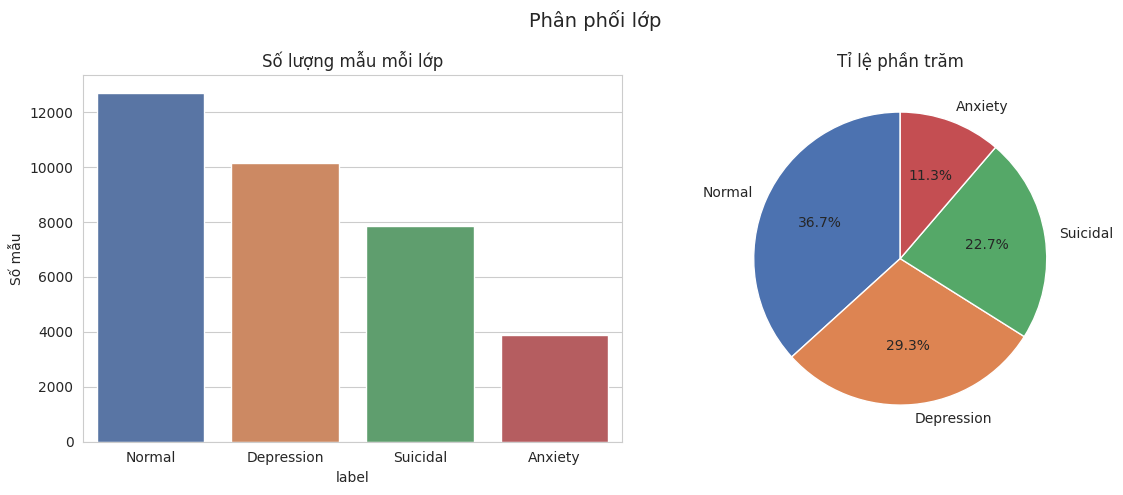

In [29]:
class_distribution(df)

# **TEXT LENGTH ANALYSIS**

In [30]:
def text_length_analysis(df):
    print("\n===== 3. Phân tích độ dài văn bản =====")
    df = df.copy()
    df['char_len'] = df[TEXT_COL].str.len()
    # word_count đã có từ basic_info nếu chạy tuần tự; tính lại để chắc chắn
    if 'word_count' not in df.columns:
        df['word_count'] = df[TEXT_COL].apply(lambda x: len(str(x).split()))

    # Thống kê theo lớp
    length_stats = df.groupby(LABEL_COL).agg(
        mean_char=('char_len', 'mean'),
        std_char=('char_len', 'std'),
        min_char=('char_len', 'min'),
        median_char=('char_len', 'median'),
        max_char=('char_len', 'max'),
        mean_word=('word_count', 'mean'),
        std_word=('word_count', 'std'),
        median_word=('word_count', 'median'),
        max_word=('word_count', 'max')
    ).round(1)
    print(length_stats)

    # Boxplot word count (bỏ outlier)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=LABEL_COL, y='word_count', palette=COLORS,
                showfliers=False, ax=ax)
    ax.set_ylabel("Số từ")
    ax.set_title("Phân phối số từ theo lớp (không vẽ outlier)")
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "word_count_boxplot.png"), dpi=DPI)
    plt.show()

    # Phân vị word count
    print("\nPhân vị số từ theo lớp:")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    for cls in CLASS_NAMES:
        vals = df[df[LABEL_COL] == cls]['word_count']
        if len(vals) == 0:
            print(f"{cls}: không có dữ liệu")
            continue
        perc_vals = np.percentile(vals, percentiles)
        print(f"{cls}: ", " | ".join([f"P{p}={int(v)}" for p, v in zip(percentiles, perc_vals)]))

    return df


===== 3. Phân tích độ dài văn bản =====
            mean_char  std_char  min_char  median_char  max_char  mean_word  \
label                                                                         
Anxiety         664.4     898.7        10        501.0     30190      126.0   
Depression      538.4     536.6         3        434.0     23386      106.8   
Normal          126.8     426.6         5         60.0     37106       24.3   
Suicidal        549.7     681.7         8        396.0     14897      109.4   

            std_word  median_word  max_word  
label                                        
Anxiety        166.7         95.0      5417  
Depression     105.7         87.0      4426  
Normal          83.4         12.0      6353  
Suicidal       131.7         80.0      2839  


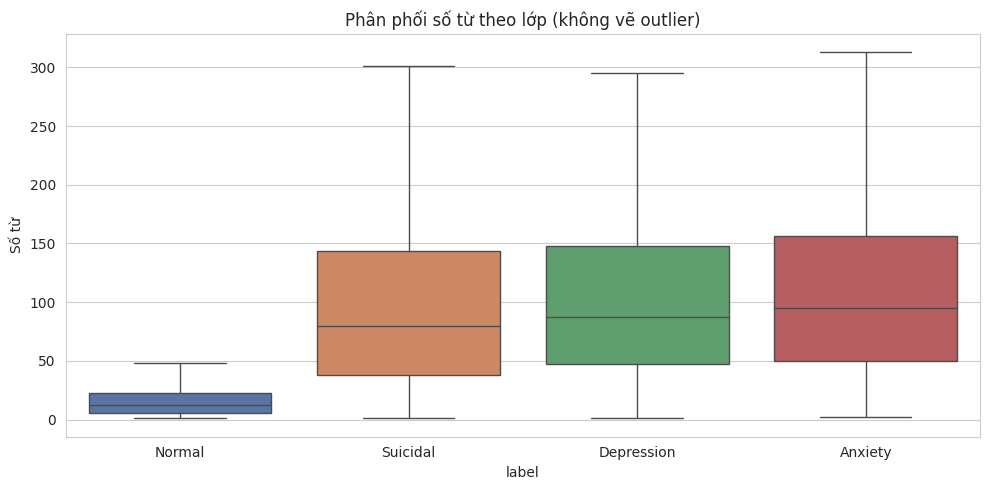


Phân vị số từ theo lớp:
Normal:  P10=4 | P25=6 | P50=12 | P75=23 | P90=57 | P95=87 | P99=163
Depression:  P10=24 | P25=47 | P50=87 | P75=148 | P90=203 | P95=230 | P99=408
Suicidal:  P10=19 | P25=38 | P50=80 | P75=144 | P90=211 | P95=251 | P99=634
Anxiety:  P10=19 | P25=50 | P50=95 | P75=156 | P90=223 | P95=320 | P99=688


In [31]:
df_enriched = text_length_analysis(df)

# **VOCABULARY ANALYSIS**

In [32]:
def vocabulary_analysis(df):
    """
    Phân tích từ vựng: Tối ưu giao diện biểu đồ, giữ nguyên logic xử lý.
    """
    print("\n===== 4. Phân tích từ vựng =====")
    df = df.copy()

    # --- Tiền xử lý ---
    def preprocess_text(text):
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', '', text)
        tokens = word_tokenize(text)
        tokens = [t for t in tokens if t not in stop_words and t.isalpha() and len(t) >= MIN_WORD_LENGTH]
        return tokens

    df['tokens'] = df[TEXT_COL].apply(preprocess_text)
    n_classes = len(CLASS_NAMES)

    # ========================
    # 1. Top từ đơn
    # ========================
    fig, axes = plt.subplots(n_classes, 1, figsize=(10, 4 * n_classes))
    if n_classes == 1: axes = [axes]

    for ax, cls in zip(axes, CLASS_NAMES):
        # Gom tokens hiệu quả hơn
        all_cls_tokens = [token for sublist in df[df[LABEL_COL] == cls]['tokens'] for token in sublist]
        counter = Counter(all_cls_tokens)
        top_words = counter.most_common(TOP_N)

        words, counts = zip(*top_words) if top_words else ([], [])

        sns.barplot(x=list(counts), y=list(words), ax=ax, palette="viridis", hue=words, legend=False)
        ax.set_title(f"Top {TOP_N} từ đơn - {cls}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Tần suất")
        ax.grid(axis='x', linestyle='--', alpha=0.6)

    fig.suptitle("Top từ đơn sau khi loại stopwords", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "top_words.png"), dpi=DPI, bbox_inches='tight')
    plt.show()

    # ========================
    # 2. Top bigrams
    # ========================
    fig, axes = plt.subplots(n_classes, 1, figsize=(10, 4 * n_classes))
    if n_classes == 1: axes = [axes]

    for ax, cls in zip(axes, CLASS_NAMES):
        # Lấy bigram từ tokens đã tiền xử lý để đồng nhất dữ liệu
        cls_tokens_list = df[df[LABEL_COL] == cls]['tokens']
        bigram_counter = Counter()
        for tokens in cls_tokens_list:
            bg_list = [' '.join(bg) for bg in ngrams(tokens, 2)]
            bigram_counter.update(bg_list)

        top_bigrams = bigram_counter.most_common(TOP_N)
        bgs, counts = zip(*top_bigrams) if top_bigrams else ([], [])

        sns.barplot(x=list(counts), y=list(bgs), ax=ax, palette="magma", hue=bgs, legend=False)
        ax.set_title(f"Top {TOP_N} Bigrams - {cls}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Tần suất")
        ax.grid(axis='x', linestyle='--', alpha=0.6)

    fig.suptitle("Top Bigrams (dựa trên tokens sạch)", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "top_bigrams.png"), dpi=DPI, bbox_inches='tight')
    plt.show()

    # ========================
    # 3. Từ đặc trưng TF-IDF
    # ========================
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES_TFIDF,
        ngram_range=NGRAMS_TFIDF,
        stop_words='english',
        sublinear_tf=True,
        min_df=3
    )
    X_tfidf = vectorizer.fit_transform(df[TEXT_COL])
    feature_names = vectorizer.get_feature_names_out()

    fig, axes = plt.subplots(n_classes, 1, figsize=(10, 4 * n_classes))
    if n_classes == 1: axes = [axes]

    for ax, cls in zip(axes, CLASS_NAMES):
        mask = (df[LABEL_COL] == cls).values
        if mask.sum() == 0:
            ax.set_title(f"TF-IDF - {cls} (Không có mẫu dữ liệu)")
            continue

        cls_tfidf_mean = X_tfidf[mask].mean(axis=0).A1
        top_indices = cls_tfidf_mean.argsort()[-TOP_N:][::-1]
        top_terms = [feature_names[j] for j in top_indices]
        top_vals = [cls_tfidf_mean[j] for j in top_indices]

        sns.barplot(x=top_vals, y=top_terms, ax=ax, palette="rocket", hue=top_terms, legend=False)
        ax.set_title(f"Từ đặc trưng TF-IDF - {cls}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Trọng số TF-IDF trung bình")
        ax.grid(axis='x', linestyle='--', alpha=0.6)

    fig.suptitle("Đặc trưng ngôn ngữ theo TF-IDF", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "tfidf_distinctive_words.png"), dpi=DPI, bbox_inches='tight')
    plt.show()

    # ========================
    # 4. Độ trùng lặp & 5. Cosine Similarity (Gộp hiển thị cạnh nhau)
    # ========================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Heatmap 1: Overlap
    vocab_sets = {cls: set([t for tokens in df[df[LABEL_COL] == cls]['tokens'] for t in tokens]) for cls in CLASS_NAMES}
    overlap_matrix = np.zeros((n_classes, n_classes))
    for i, cls1 in enumerate(CLASS_NAMES):
        for j, cls2 in enumerate(CLASS_NAMES):
            inter = len(vocab_sets[cls1].intersection(vocab_sets[cls2]))
            uni = len(vocab_sets[cls1].union(vocab_sets[cls2]))
            overlap_matrix[i, j] = (inter / uni * 100) if uni > 0 else 0

    sns.heatmap(overlap_matrix, annot=True, fmt='.1f', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, cmap='YlOrRd', ax=ax1, cbar_kws={'label': '% Overlap'})
    ax1.set_title("Độ trùng lặp từ vựng (Jaccard %)", fontweight='bold')

    # Heatmap 2: Cosine Similarity
    centroids = []
    for cls in CLASS_NAMES:
        mask = (df[LABEL_COL] == cls).values
        centroids.append(X_tfidf[mask].mean(axis=0).A1 if mask.sum() > 0 else np.zeros(X_tfidf.shape[1]))

    sim_matrix = cosine_similarity(centroids)
    sns.heatmap(sim_matrix, annot=True, fmt='.3f', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, cmap='Blues', ax=ax2)
    ax2.set_title("Cosine Similarity (TF-IDF Centroids)", fontweight='bold')

    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "vocabulary_similarity.png"), dpi=DPI)
    plt.show()

    # ========================
    # 6. Đa dạng từ vựng (TTR)
    # ========================
    ttr_data = []
    for cls in CLASS_NAMES:
        subset = df[df[LABEL_COL] == cls]
        ttrs = subset['tokens'].apply(lambda x: len(set(x)) / len(x) if len(x) > 0 else 0)
        ttr_data.append({'Lớp': cls, 'Mean TTR': ttrs.mean(), 'Median TTR': ttrs.median()})

    ttr_df = pd.DataFrame(ttr_data).set_index('Lớp')

    ax = ttr_df.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'], width=0.7)
    plt.title('Đa dạng từ vựng (Type-Token Ratio) theo lớp', fontsize=14, fontweight='bold')
    plt.ylabel('Tỉ lệ TTR')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(frameon=True)

    # Thêm giá trị lên đầu cột
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10),
                    textcoords='offset points', fontsize=9)

    plt.ylim(0, max(ttr_df['Mean TTR'].max(), ttr_df['Median TTR'].max()) * 1.2)
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "ttr_diversity.png"), dpi=DPI)
    plt.show()


===== 4. Phân tích từ vựng =====


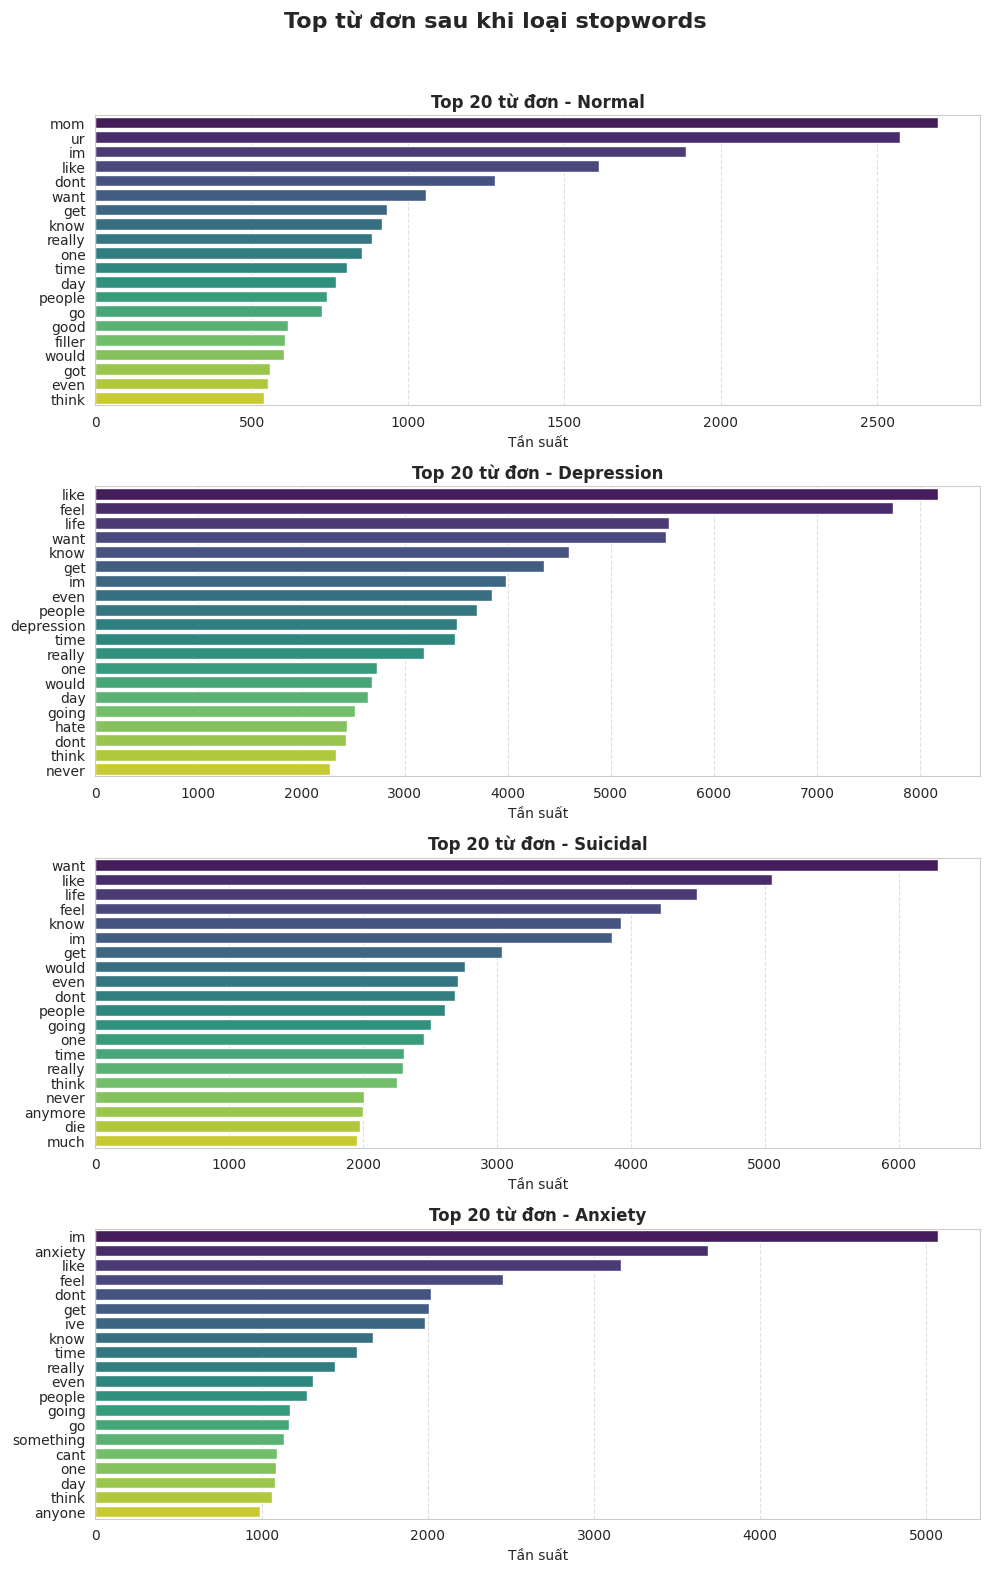

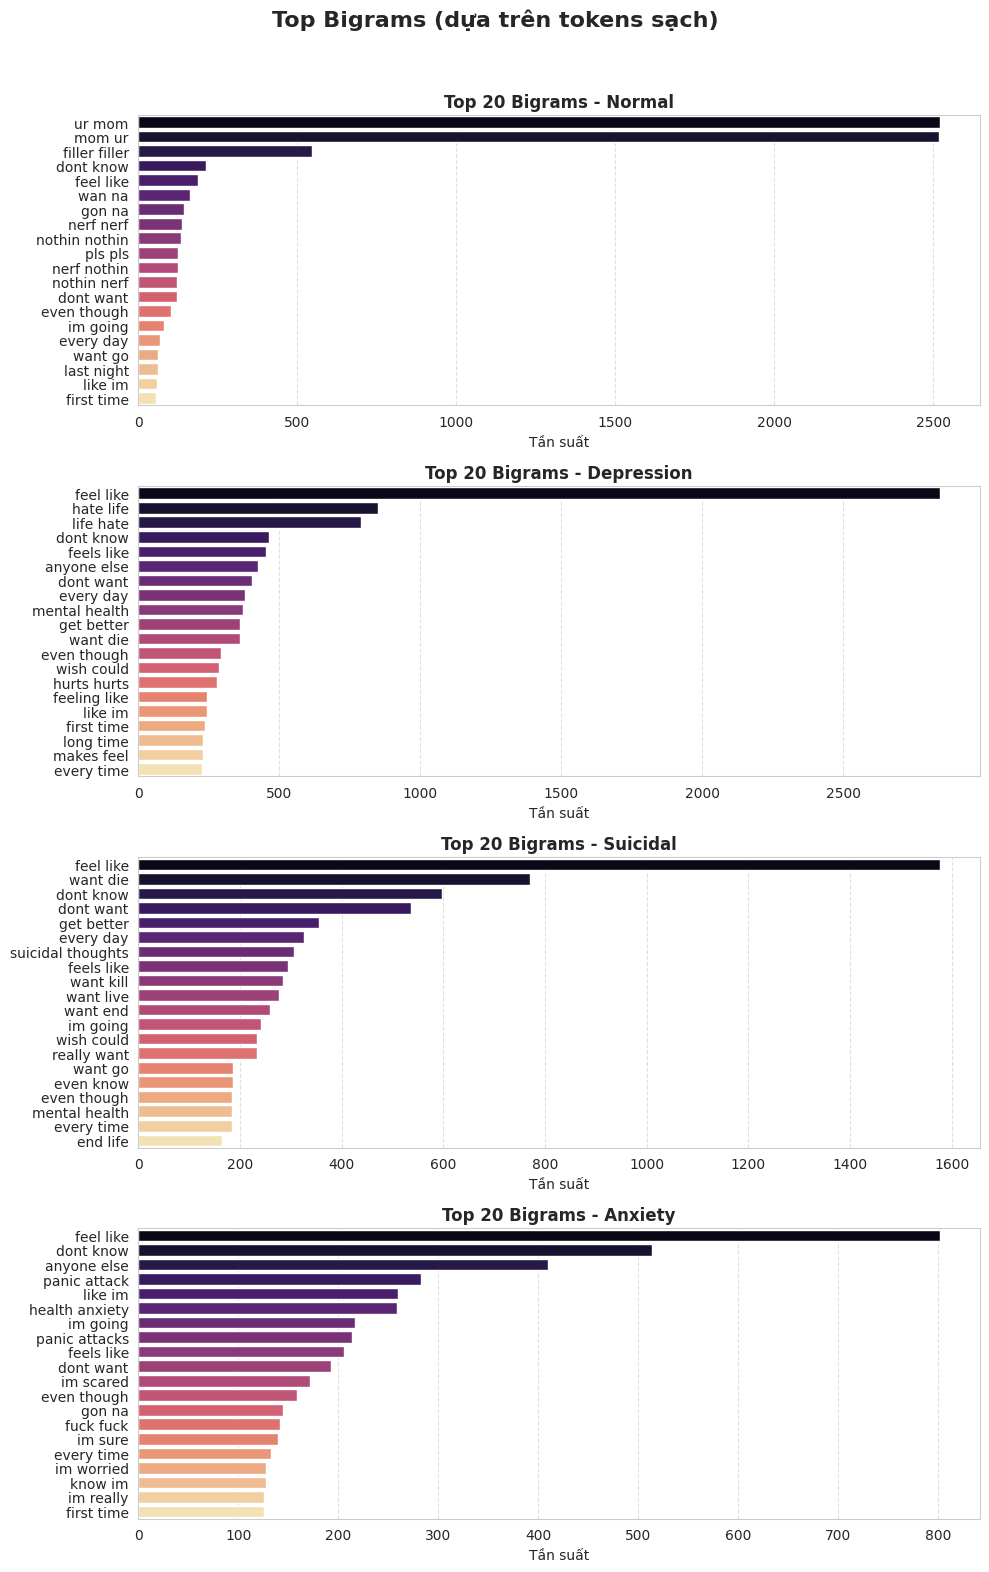

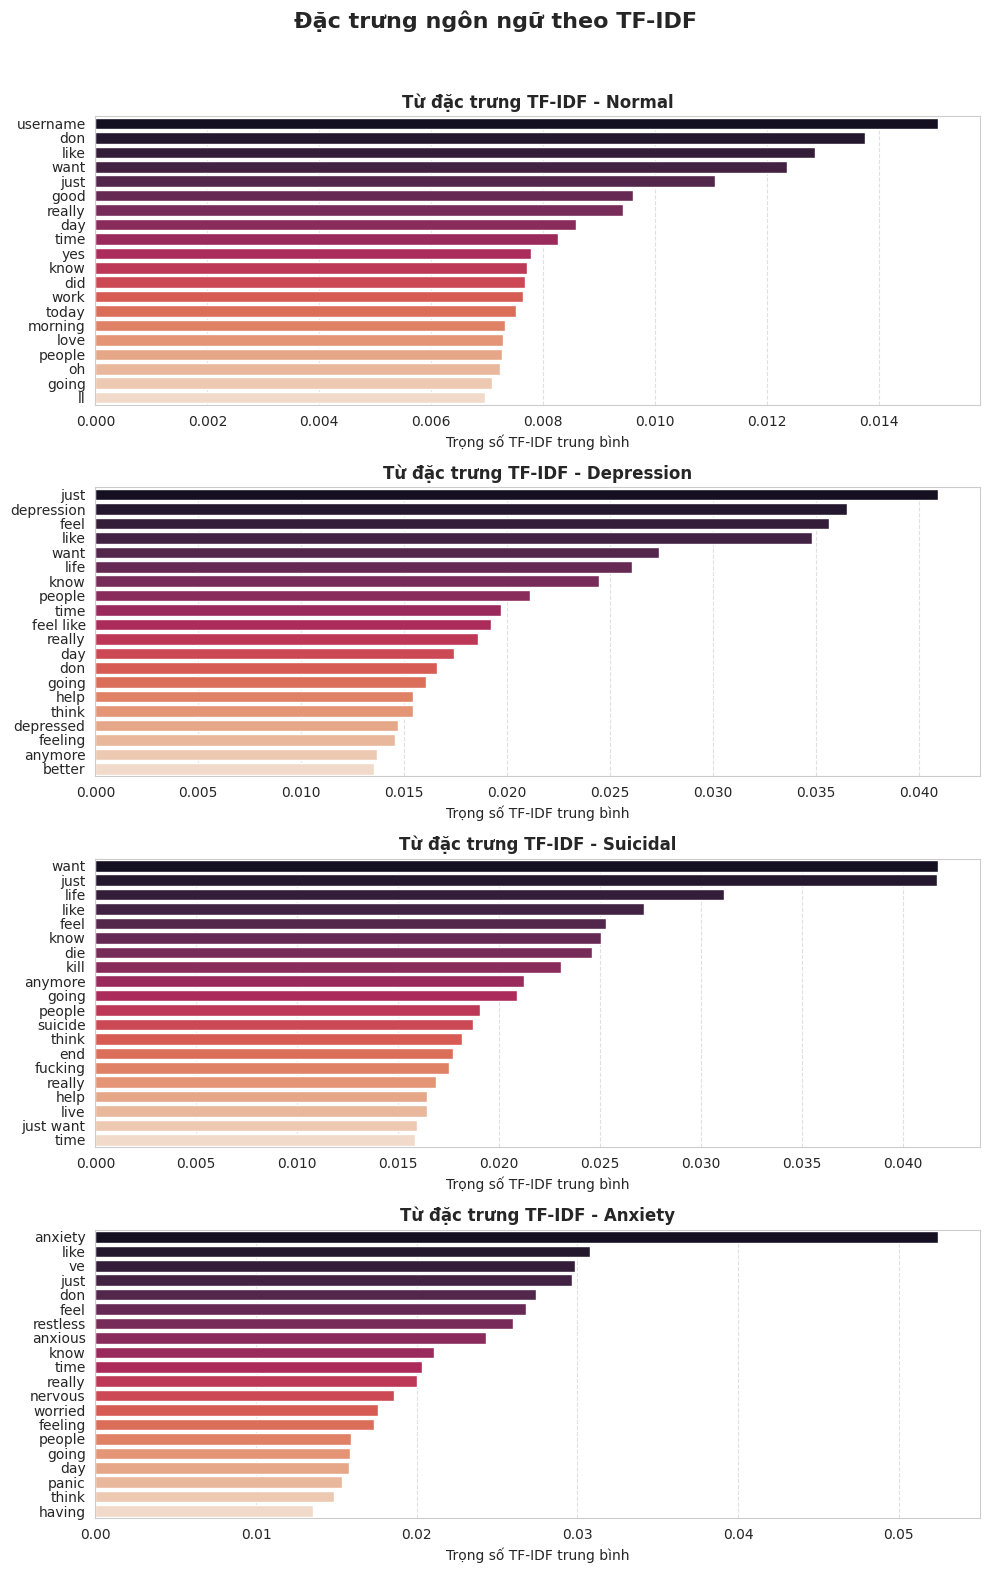

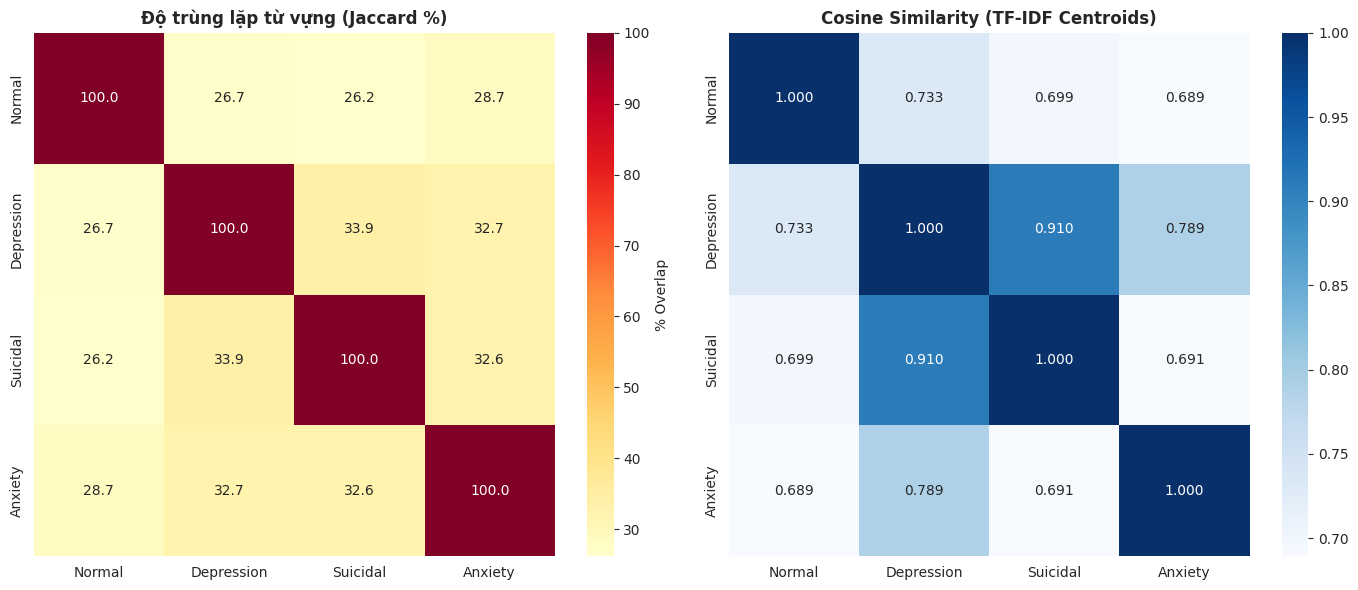

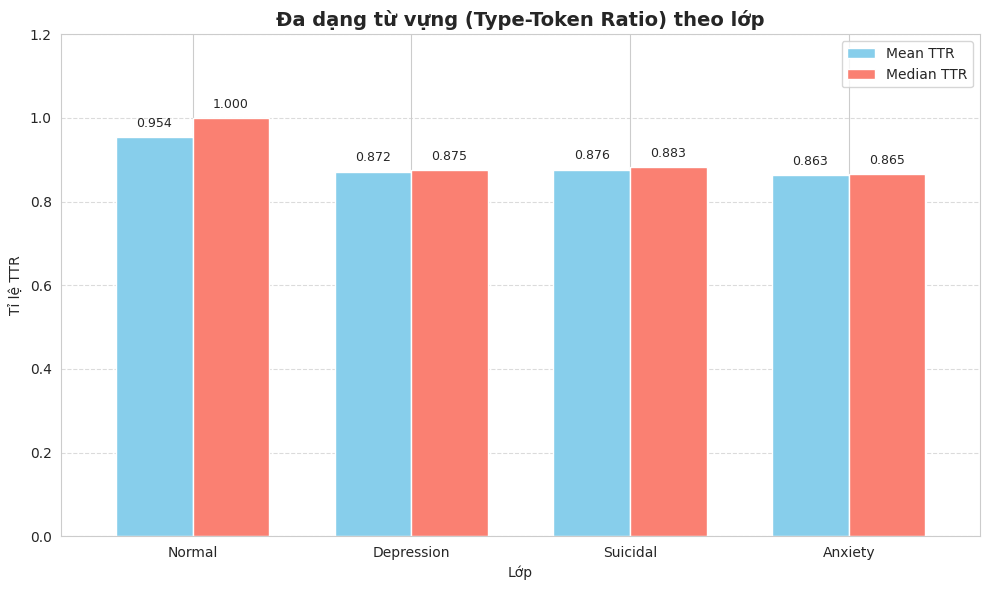

In [33]:
vocabulary_analysis(df)

# **FEATURE CORRELATION ANALYSIS**

In [34]:
def feature_correlation_analysis(df):
    # (Giữ nguyên phần tính toán đặc trưng)
    df = df.copy()
    df['char_len'] = df[TEXT_COL].str.len()
    if 'word_count' not in df.columns:
        df['word_count'] = df[TEXT_COL].apply(lambda x: len(str(x).split()))

    df['avg_word_len'] = df.apply(lambda row: row['char_len'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1)
    df['unique_words'] = df[TEXT_COL].apply(lambda x: len(set(str(x).lower().split())))
    df['lexical_diversity'] = df.apply(lambda row: row['unique_words'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1)
    df['exclam_count'] = df[TEXT_COL].apply(lambda x: x.count('!'))
    df['question_count'] = df[TEXT_COL].apply(lambda x: x.count('?'))
    df['caps_ratio'] = df[TEXT_COL].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(1, len(str(x))))
    df['url_count'] = df[TEXT_COL].apply(lambda x: len(re.findall(r'http', str(x))))
    df['ellipsis_count'] = df[TEXT_COL].apply(lambda x: x.count('...'))

    feature_cols = [
        'char_len', 'word_count', 'avg_word_len', 'unique_words', 'lexical_diversity',
        'exclam_count', 'question_count', 'caps_ratio', 'url_count', 'ellipsis_count'
    ]
    feature_labels = [
        'Char Len', 'Word Cnt', 'Avg Wrd Len', 'Unique Wrds', 'Lex Div',
        'Exclaim', 'Question', 'Caps Ratio', 'URLs', 'Ellipsis'
    ]

    # 1. Tính toán ma trận tương quan
    corr = df[feature_cols].corr()
    corr.index = feature_labels
    corr.columns = feature_labels

    # 2. Vẽ Heatmap (Thay thế cho lệnh print)
    plt.figure(figsize=(12, 10))

    # Tạo mask để ẩn nửa tam giác trên (giúp biểu đồ thoáng hơn)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Vẽ heatmap bằng seaborn
    heatmap = sns.heatmap(
        corr,
        mask=mask,
        annot=True,           # Hiển thị số liệu trên từng ô
        fmt='.2f',            # Làm tròn 2 chữ số thập phân
        cmap='RdBu_r',        # Màu đỏ (dương) - xanh (âm) trực quan hơn
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )

    plt.title("Ma trận tương quan giữa các đặc trưng văn bản", fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    # Lưu file nếu có đường dẫn
    if 'FIG_DIR' in globals() and FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "feature_correlation_heatmap.png"),
                    dpi=globals().get('DPI', 300), bbox_inches='tight')

    plt.show()

    return df

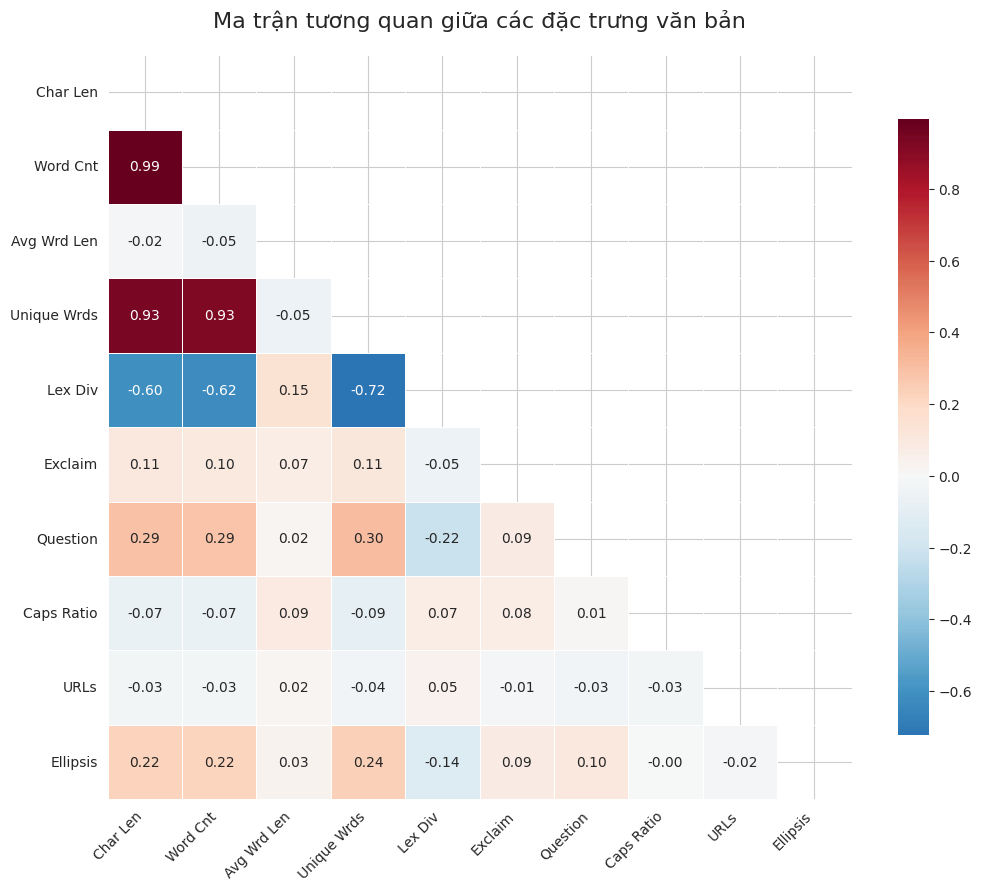

In [35]:
df_features = feature_correlation_analysis(df_enriched)

In [36]:
def feature_label_analysis(df):
    df = df.copy()

    # Kiểm tra đặc trưng đầu vào
    feature_cols = [
        'char_len', 'word_count', 'avg_word_len', 'unique_words', 'lexical_diversity',
        'exclam_count', 'question_count', 'caps_ratio', 'url_count', 'ellipsis_count'
    ]
    feature_labels = [
        'Char Len', 'Word Cnt', 'Avg Wrd Len', 'Unique Wrds', 'Lex Div',
        'Exclaim', 'Question', 'Caps Ratio', 'URLs', 'Ellipsis'
    ]

    if not all(col in df.columns for col in feature_cols):
        # Giả sử hàm này đã được định nghĩa trước đó
        df = feature_correlation_analysis(df)

    # 1. Tính toán ANOVA F-score
    le = LabelEncoder()
    y = le.fit_transform(df[LABEL_COL])
    f_scores, p_values = f_classif(df[feature_cols], y)

    importance_df = pd.DataFrame({
        'Feature': feature_labels,
        'F-score': f_scores,
        'p-value': p_values,
        'Original_Col': feature_cols
    }).sort_values('F-score', ascending=False)

    # ---------- TRỰC QUAN HÓA ----------

    # Thiết lập giao diện
    sns.set_style("whitegrid")
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2) # Chia lưới: hàng 1 cho Bar chart, hàng 2-3 cho Boxplots

    # BIỂU ĐỒ 1: Xếp hạng mức độ quan trọng (F-score)
    ax_bar = fig.add_subplot(gs[0, :])
    colors = sns.color_palette("viridis", len(importance_df))
    sns.barplot(data=importance_df, x='F-score', y='Feature', palette=colors, ax=ax_bar)
    ax_bar.set_title("Xếp hạng mức độ quan trọng của đặc trưng (ANOVA F-test)", fontsize=15, fontweight='bold')
    ax_bar.set_xlabel("F-score (Càng cao càng quan trọng)")

    # Thêm text p-value nhỏ bên cạnh các cột
    for i, p in enumerate(importance_df['p-value']):
        ax_bar.text(importance_df['F-score'].iloc[i], i, f" p={p:.2e}", va='center', fontsize=9)

    # BIỂU ĐỒ 2: Top 4 Boxplots (Sự khác biệt giữa các nhãn)
    top_4 = importance_df.head(4)
    for i, (idx, row) in enumerate(top_4.iterrows()):
        ax_box = fig.add_subplot(gs[1 + i // 2, i % 2])

        # Vẽ Boxplot kết hợp với Stripplot (tùy chọn) để thấy phân tán dữ liệu
        sns.boxplot(
            data=df, x=LABEL_COL, y=row['Original_Col'],
            palette='Set2', ax=ax_box, showfliers=False, width=0.6
        )

        # Thêm tiêu đề cho từng biểu đồ con
        ax_box.set_title(f"Phân phối: {row['Feature']}", fontsize=12, fontweight='bold', color='darkblue')
        ax_box.set_ylabel("Giá trị")
        ax_box.set_xlabel("Nhãn (Label)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle("PHÂN TÍCH MỐI TƯƠNG QUAN ĐẶC TRƯNG VÀ NHÃN", fontsize=18, fontweight='bold')

    # Lưu và hiển thị
    if 'FIG_DIR' in globals() and FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "feature_label_insight.png"), dpi=globals().get('DPI', 300))

    plt.show()

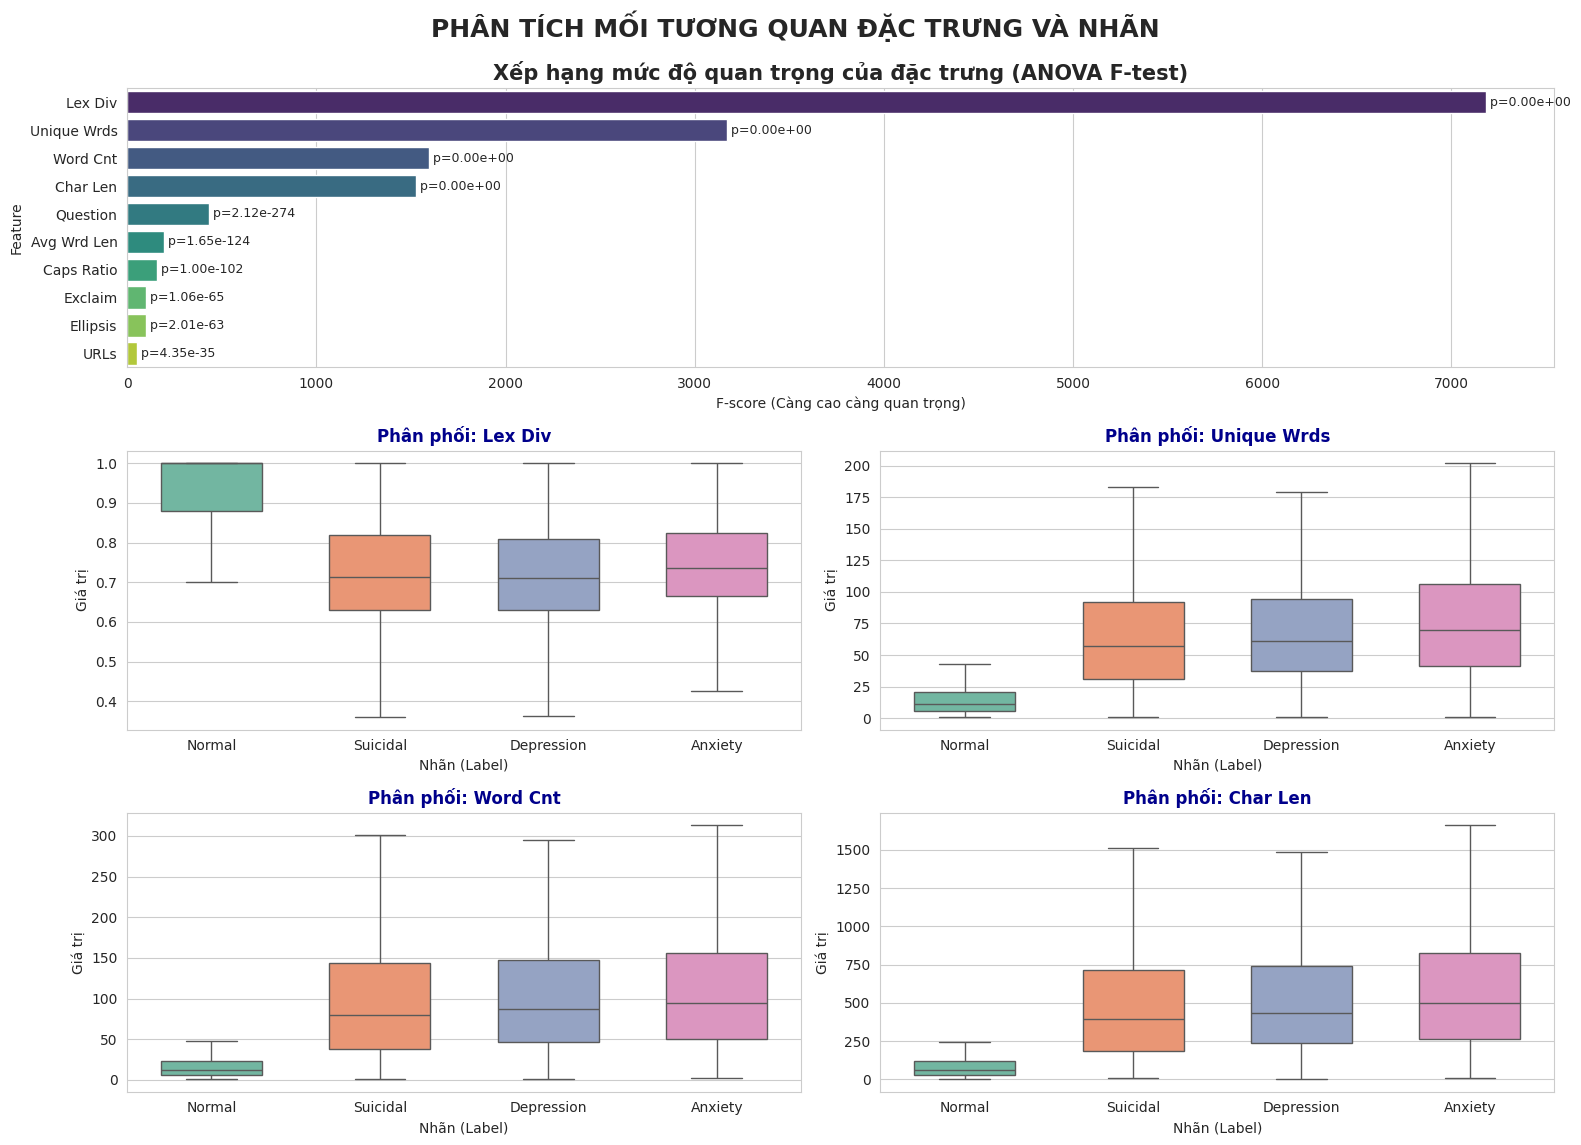

In [37]:
feature_label_analysis(df_features)

# DATA QUALITY ANALYSIS

In [38]:
def data_quality_analysis(df):
    print("\n===== Phân tích Chất lượng dữ liệu =====")
    df = df.copy()

    # ----- Các hàm phát hiện noise -----
    def count_non_ascii(text):
        return sum(1 for c in str(text) if ord(c) > 127)

    def count_urls(text):
        return len(re.findall(r'http[s]?://\S+|www\.\S+', str(text)))

    def count_mentions(text):
        return len(re.findall(r'@\w+', str(text)))

    # MỚI: Hàm đếm hashtag
    def count_hashtags(text):
        return len(re.findall(r'#\w+', str(text)))

    def count_repeated_chars(text, n=5):
        return len(re.findall(r'(.)\1{' + str(n-1) + r',}', str(text)))

    def is_short_text(text, thresh=SHORT_TEXT_THRESHOLD):
        return len(str(text).split()) <= thresh

    def has_html(text):
        html_pattern = re.compile(r'<(?!(?:username|url|user|name|number)\b)[^>]+>')
        return bool(html_pattern.search(str(text)))

    # ----- Phát hiện emoji -----
    try:
        import emoji
        def has_emoji(text):
            return bool(emoji.emoji_count(str(text)))
    except ImportError:
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
            "\U0001F1E0-\U0001F1FF\U00002600-\U000026FF\U00002700-\U000027BF"
            "\U0000FE00-\U0000FE0F\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F"
            "\U0001FA70-\U0001FAFF"
            "]+", flags=re.UNICODE)
        def has_emoji(text):
            return bool(emoji_pattern.search(str(text)))

    # ----- Phát hiện mojibake -----
    mojibake_pattern = re.compile(
        r'Ã[©¢£¤¥§]|Ã[¨©ª«¬­®¯]|â[€‚ƒ„…†‡ˆ‰Š‹ŒŽ]|â[‘’“”•–—˜™š›œžŸ]|Â[¡¢£¤¥¦§¨©ª«¬­®¯]')
    def has_mojibake(text):
        return bool(mojibake_pattern.search(str(text)))

    # ----- Gán cờ cho từng mẫu -----
    df['has_non_ascii'] = df[TEXT_COL].apply(lambda x: count_non_ascii(x) > 0)
    df['url_flag'] = df[TEXT_COL].apply(lambda x: count_urls(x) > 0)
    df['mention_flag'] = df[TEXT_COL].apply(lambda x: count_mentions(x) > 0)
    df['hashtag_flag'] = df[TEXT_COL].apply(lambda x: count_hashtags(x) > 0) # MỚI
    df['repeated_char'] = df[TEXT_COL].apply(lambda x: count_repeated_chars(x, 5) > 0)
    df['is_short'] = df[TEXT_COL].apply(is_short_text)
    df['has_emoji_flag'] = df[TEXT_COL].apply(has_emoji)
    df['has_mojibake_flag'] = df[TEXT_COL].apply(has_mojibake)
    df['has_html_flag'] = df[TEXT_COL].apply(has_html)

    # Tính tỉ lệ % tổng quát
    issue_dict = {
        'Non-ASCII': df['has_non_ascii'].mean() * 100,
        'Chứa URL': df['url_flag'].mean() * 100,
        'Chứa @mention': df['mention_flag'].mean() * 100,
        'Chứa #hashtag': df['hashtag_flag'].mean() * 100, # MỚI
        'Ký tự lặp (≥5)': df['repeated_char'].mean() * 100,
        'Văn bản ngắn': df['is_short'].mean() * 100,
        'Có emoji': df['has_emoji_flag'].mean() * 100,
        'Có mojibake': df['has_mojibake_flag'].mean() * 100,
        'Chứa HTML': df['has_html_flag'].mean() * 100
    }

    print("Tỉ lệ % các vấn đề trên toàn bộ dataset:")
    for k, v in issue_dict.items():
        print(f"  - {k}: {v:.2f}%")

    # 1. Biểu đồ thanh: Tổng quan các vấn đề
    plt.figure(figsize=(12, 5))
    bars = plt.bar(issue_dict.keys(), issue_dict.values(), color='#8B5CF6')
    plt.ylabel("Phần trăm (%) mẫu vi phạm")
    plt.title("Tổng quan các vấn đề chất lượng dữ liệu")
    plt.xticks(rotation=30, ha='right')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center')
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "data_quality_overview.png"), dpi=DPI)
    plt.show()

    # 2. Biểu đồ Heatmap: Tỉ lệ vấn đề theo từng Lớp
    # TỔNG HỢP: Thêm 'hashtag_flag' vào list bên dưới
    cross = df.groupby(LABEL_COL)[['has_non_ascii', 'repeated_char', 'is_short',
                                   'url_flag', 'mention_flag', 'hashtag_flag', # MỚI
                                   'has_emoji_flag', 'has_mojibake_flag', 'has_html_flag']].mean() * 100

    cross.columns = ['Non-ASCII', 'Ký tự lặp', 'Ngắn', 'URL', '@Mention', 'Hashtag', 'Emoji', 'Mojibake', 'HTML']

    plt.figure(figsize=(14, 8))
    sns.heatmap(cross, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Phần trăm (%)'})
    plt.title("Tỉ lệ vấn đề chất lượng dữ liệu phân bố theo Lớp")
    plt.xlabel("Loại vấn đề")
    plt.ylabel("Lớp (Class)")
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "data_quality_by_class.png"), dpi=DPI)
    plt.show()

    # ----- Liệt kê các mẫu ví dụ (Sử dụng Sample ngẫu nhiên) -----
    print("\n--- Ví dụ các mẫu văn bản chứa lỗi (Lấy ngẫu nhiên) ---")
    noise_types = {
        'Chứa HTML': 'has_html_flag',
        'Chứa URL': 'url_flag',
        'Chứa Hashtag': 'hashtag_flag', # MỚI
        'Ký tự lặp': 'repeated_char',
        'Mojibake': 'has_mojibake_flag',
        'Văn bản ngắn': 'is_short'
    }

    for noise_name, flag_col in noise_types.items():
        subset = df[df[flag_col]][TEXT_COL]
        n_total = len(subset)
        n_samples = min(5, n_total) # Lấy tối đa 5 mẫu

        print(f"\n{noise_name} (Tổng {n_total} mẫu):")
        if n_samples == 0:
            print("  (Không tìm thấy mẫu nào)")
        else:
            samples = subset.sample(n_samples, random_state=1000)
            for i, text in enumerate(samples, 1):
                display_text = str(text).replace('\n', ' ')
                print(f"  [{i}] {display_text}")


===== Phân tích Chất lượng dữ liệu =====
Tỉ lệ % các vấn đề trên toàn bộ dataset:
  - Non-ASCII: 0.00%
  - Chứa URL: 0.00%
  - Chứa @mention: 0.00%
  - Chứa #hashtag: 0.02%
  - Ký tự lặp (≥5): 0.35%
  - Văn bản ngắn: 2.64%
  - Có emoji: 0.00%
  - Có mojibake: 0.00%
  - Chứa HTML: 0.03%


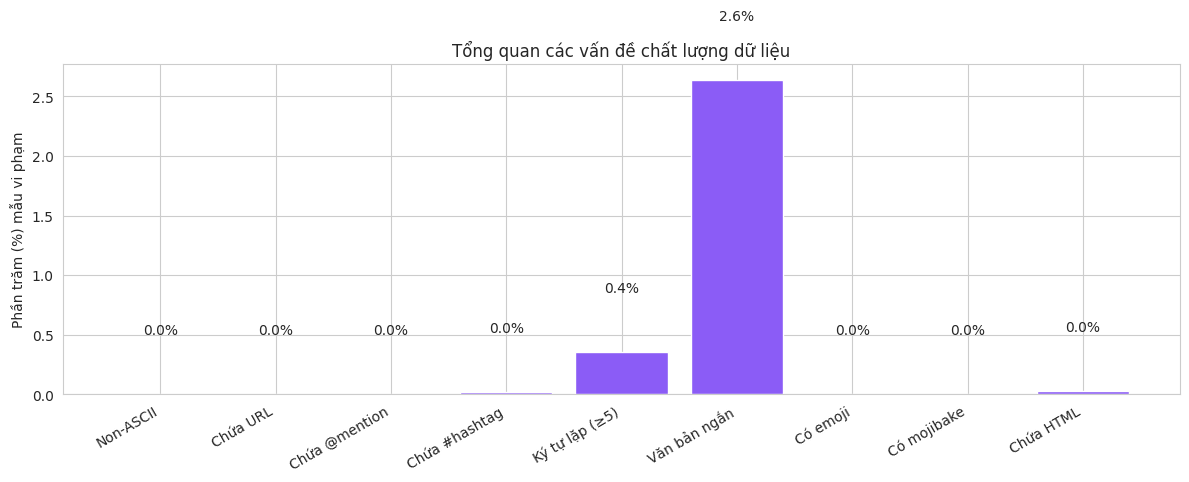

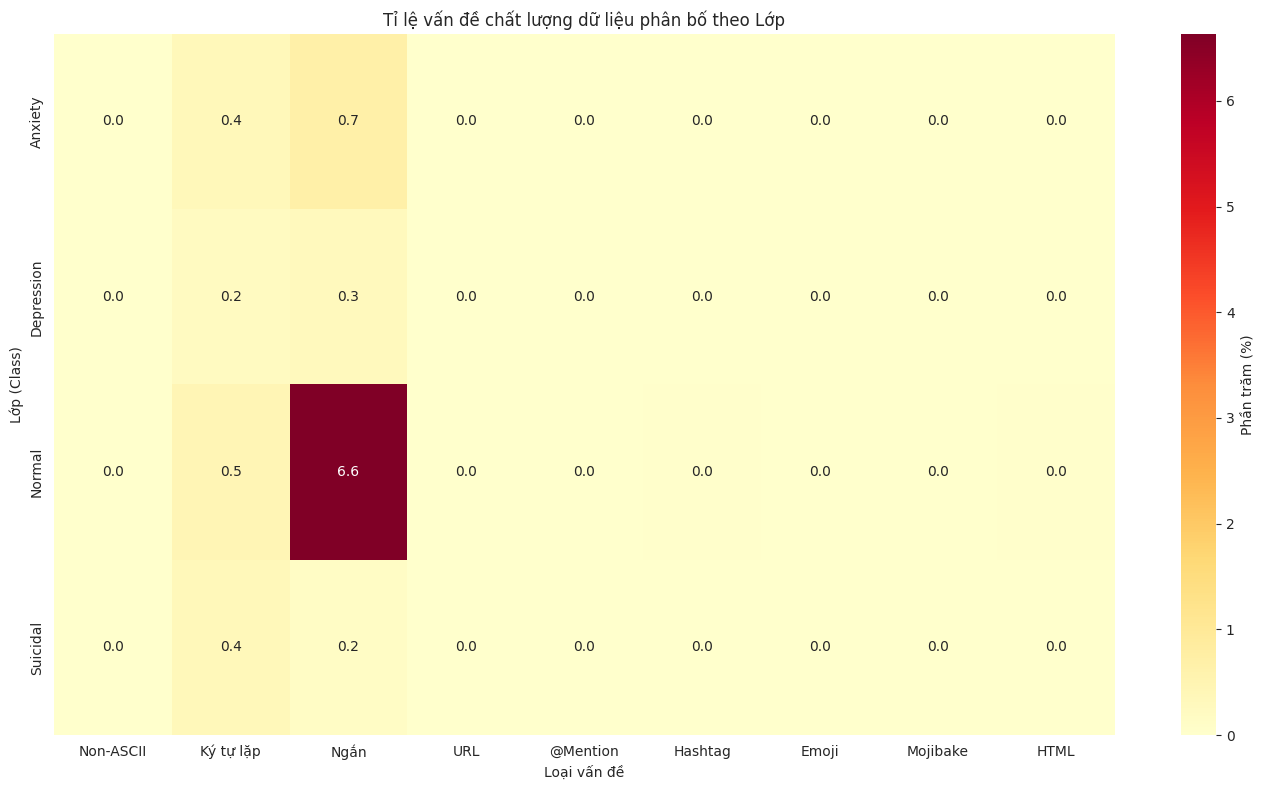


--- Ví dụ các mẫu văn bản chứa lỗi (Lấy ngẫu nhiên) ---

Chứa HTML (Tổng 11 mẫu):
  [1] my therapist called me this afternoon after the office texted me about scheduling appointments and i said i wasn't sure i wanted to continue because therapy hasn't helped at all. she asked me how i was and i told her nothing has changed, things are worse, i am so lonely i want to die. she said "mhmm... i'm sure that's frustrating." and ended the call shortly thereafter telling me good luck in the future. lol. pretty sure she never once listened to a word i said, all i ever got back from her were canned "empathetic" phrases. i was hanging in but that phone call made me start to sob, just another person who doesn't care even when i'm paying them to care. and i wonder why therapy wasn't helping, turns out i need a little more help than "i know it's frustrating when <repeats everything i just said back to me>". you need a phd in psychology for that? good riddance.
  [2] emotion? ?! emotion. . emotion ?

In [39]:
data_quality_analysis(df_enriched)

In [40]:
print("\nHoàn tất EDA. Các hình đã được lưu trong thư mục", FIG_DIR if FIG_DIR else "không lưu")


Hoàn tất EDA. Các hình đã được lưu trong thư mục figures
